# BJTF Model — System Identification Walkthrough

This notebook demonstrates the four-step system identification process for a **two-variable, input-output** system using the **Box-Jenkins Transfer Function (BJTF)** model class.

| Step | Task | Tool |
|------|------|------|
| 1 | Choose a model class | Identify input-output structure; zero-mean both signals |
| 2 | Select model order | `uniAnal` on u → ARMA model for u; `multiAnal` → impulse response, G/H GPAC |
| 3 | Estimate parameters | `estimate`, `pmoddisp`, `pmodpzplot` |
| 4 | Validate the model | `multiChi` — whiteness test (Q) and cross-correlation test (S) |

**Dataset:** Box-Jenkins Series J — Gas Furnace (296 observations)
Input u: gas flow rate (ft³/min, zero-meaned); Output y: percent CO₂ in exit gas (zero-meaned)

## BJTF Model Structure

The BJTF model separates the input-output dynamics (G) from the noise dynamics (H):

$$y(t) = G(q^{-1})\,u(t-k) + H(q^{-1})\,e(t)$$

where

$$G(q^{-1}) = \frac{B(q^{-1})}{F(q^{-1})} = \frac{b_0 + b_1 q^{-1} + \cdots + b_{n_b} q^{-n_b}}{1 + f_1 q^{-1} + \cdots + f_{n_f} q^{-n_f}}$$

$$H(q^{-1}) = \frac{C(q^{-1})}{D(q^{-1})} = \frac{1 + c_1 q^{-1} + \cdots + c_{n_c} q^{-n_c}}{1 + d_1 q^{-1} + \cdots + d_{n_d} q^{-n_d}}$$

$k$ is a pure time delay and $e(t)$ is white noise with variance $\sigma^2$.

BJTF is an **output-error** model: G and H are estimated independently, giving the most flexible representation when the disturbance model differs from the input dynamics.  Compare to ARMAX (equation-error), where G and H share the same denominator polynomial A.

In PredictMod notation:
```python
pmodel('bjtf', nb=[nb], nf=[nf], nc=[nc], nd=[nd], delay=[k], diff=[0], per=[])
```

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import pandas as pd

current_dir = os.getcwd()
timeseries_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
if timeseries_root not in sys.path:
    sys.path.insert(0, timeseries_root)

from TimeSeriesSRC.Model.model import pmodel
from TimeSeriesSRC.Model.estimate import estimate
from TimeSeriesSRC.Model.selpmod import func_selpmod as selpmod
from TimeSeriesSRC.Model.pmodaic import func_pmodaic as pmodaic
from TimeSeriesSRC.Model.pmodbic import func_pmodbic as pmodbic
from TimeSeriesSRC.basefunctions.uniAnal import func_uniAnal as uniAnal
from TimeSeriesSRC.basefunctions.multiAnal import func_multiAnal as multiAnal
from TimeSeriesSRC.basefunctions.uniChi import func_uniChi as uniChi
from TimeSeriesSRC.basefunctions.multiChi import func_multiChi as multiChi
from TimeSeriesSRC.basefunctions.partoacf import func_partoacf_pmod as partoacf_pmod
from TimeSeriesSRC.Model.pmodmse import func_pmodmse as pmodmse
from TimeSeriesSRC.Model.pmoddisp import func_pmoddisp as pmoddisp
from TimeSeriesSRC.Model.pmoddisp import func_pmodpzplot as pmodpzplot

np.random.seed(42)
print('Setup complete.')

Setup complete.


Loaded gas furnace data: N=296 samples
u: mean=4.80e-17, std=1.071
y: mean=4.51e-15, std=3.197


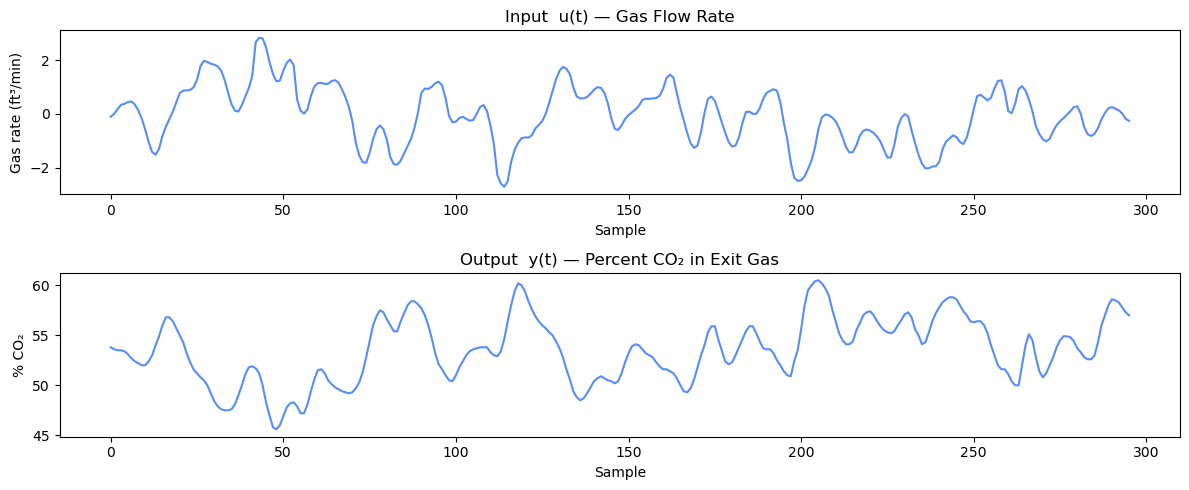

In [20]:
data_path = os.path.join(timeseries_root, 'TimeSeriesSRC', 'TestData',
                         'Series_J_Gas_Furnace.csv')
df    = pd.read_csv(data_path)
u_raw = np.array(df['InputGasRate'], dtype=float)
y_raw = np.array(df['CO2'],          dtype=float)

u = u_raw - u_raw.mean()
y = y_raw - y_raw.mean()
N = y.size

print(f'Loaded gas furnace data: N={N} samples')
print(f'u: mean={u.mean():.2e}, std={u.std():.3f}')
print(f'y: mean={y.mean():.2e}, std={y.std():.3f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(u_raw)
axes[0].set_title('Input  u(t) — Gas Flow Rate')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Gas rate (ft³/min)')
axes[1].plot(y_raw)
axes[1].set_title('Output  y(t) — Percent CO₂ in Exit Gas')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('% CO₂')
plt.tight_layout()
plt.show()

## Step 1 — Choose a Model Class

The gas furnace experiment measures a **cause-and-effect relationship**: the gas flow rate u(t) is manipulated and the CO₂ concentration y(t) responds after a delay.  This input-output structure points to a model with both a **transfer function** G from u to y and a separate **noise model** H for the unmeasured disturbance.

Three candidate model classes are compared in this notebook:

| Model | Structure | Key property |
|-------|-----------|-------------|
| **BJTF** | $y = \frac{B}{F} u + \frac{C}{D} e$ | Output-error: G and H estimated independently — most flexible |
| **ARMAX** | $A\,y = B\,u + C\,e$ | Equation-error: G and H share the same poles (A) |
| **ARX** | $A\,y = B\,u + e$ | Simplest equation-error: H = 1/A, no MA term |

We work through the full four-step process for **BJTF** and use `selpmod` to compare ARMAX and ARX at the end.

## Step 2 — Select Model Order

### Step 2a — Univariate Analysis of the Input u

Before fitting the BJTF model, we model u(t) as an ARMA process.  This serves two purposes:

1. **Prewhitening** — `multiAnal` uses the ARMA model to prewhiten u before computing the impulse response and G/H GPAC arrays.  An accurate input model sharpens the cross-correlation estimates.
2. **Preliminary structure check** — the ACF, PACF, and GPAC of u reveal its autocorrelation structure independently of y.

We apply `uniAnal` to identify the ARMA order for u.

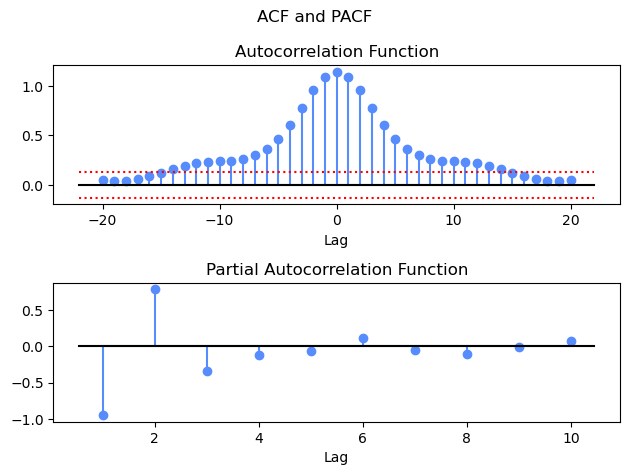

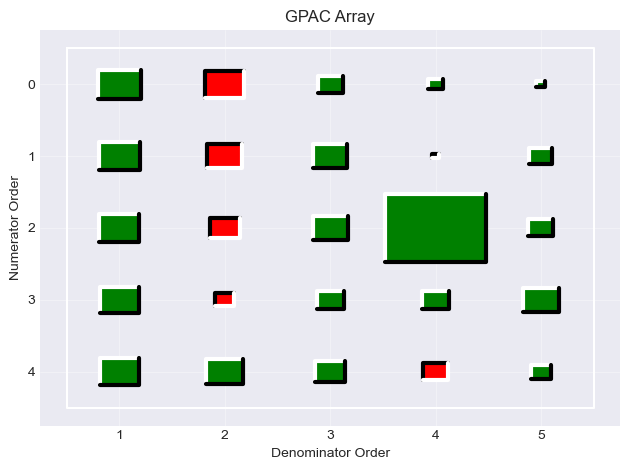

GPAC for u:
[[ 0.952 -0.788  0.339  0.121  0.059]
 [ 0.876 -0.633  0.588 -0.041  0.287]
 [ 0.817 -0.472  0.621  5.     0.335]
 [ 0.779 -0.199  0.391  0.367  0.671]
 [ 0.767  0.685  0.46  -0.299  0.224]]


In [3]:
uacf, upacf, ugpac = uniAnal(u, 20, 10)
print('GPAC for u:')
print(np.round(ugpac, 3))

### ACF/GPAC Interpretation for u

Key features in the correlation structure of u:

- The **PACF** cuts off sharply after lag 3, with negligible values beyond.
- The **GPAC** shows an approximately constant value in **column 3** starting from row 1, with near-zero entries in columns 1 and 2.

This is the signature of a pure **AR(3)** process — an ARMA model with $n_c = 0$ (no MA terms) and $n_d = 3$ (three AR terms).

### Step 2b — Fit and Validate the ARMA(0, 3) Model for u

We fit the AR(3) model and inspect parameter confidence intervals, the residual ACF, and the chi-square statistic.

Epoch 0/100 Time 0.021348953247070312 PMODMSE 1.4073348483018802/0 Gradient 565.9039021710234/0.0001 mu 0.001/10000000000.0


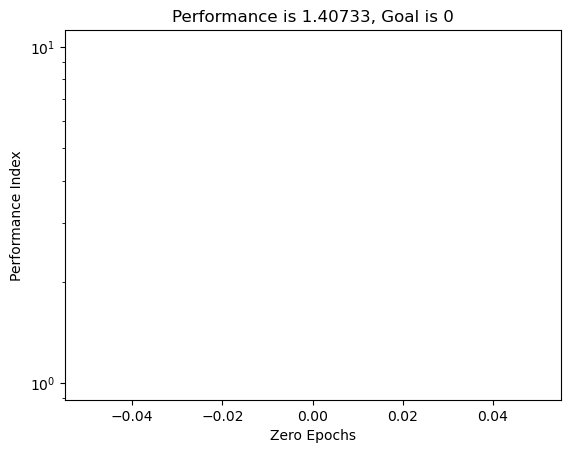

8.995961100382583e-08 0.0001
Epoch 2/100 Time 0.30977296829223633 PMODMSE 0.035357034664973426/0 Gradient 8.995961100382583e-08/0.0001 mu 1e-05/10000000000.0


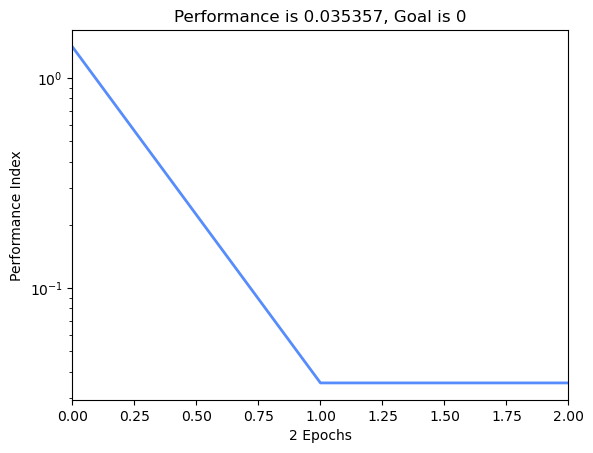

ESTIMLM, Minimum gradient reached, performance goal was not met.


Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  d1      -1.9749       0.1092   (   -2.0841,    -1.8656)
  d2       1.3732       0.1980   (    1.1752,     1.5712)
  d3      -0.3425       0.1093   (   -0.4518,    -0.2332)

  Residual std  σ = 0.188035
  Residual var  σ² = 0.035357


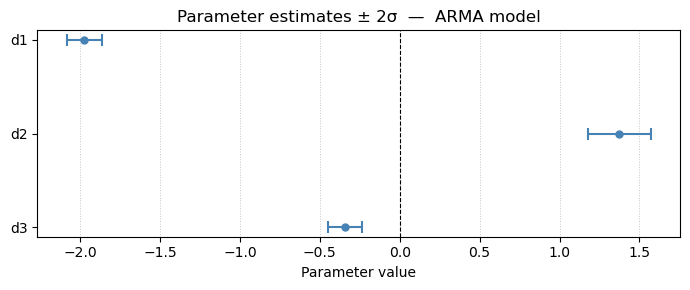

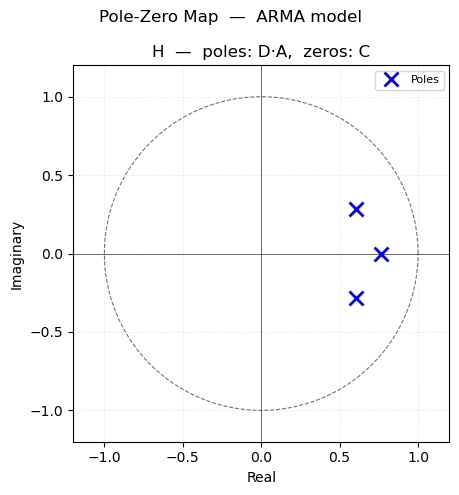

In [4]:
pmod_u = pmodel('arma', nc=[0], nd=[3], diff=[0], per=[])
pmod_u, trec_u, stat_u = estimate(pmod_u, u)
pmoddisp(pmod_u, stat_u)
pmodpzplot(pmod_u)
plt.show()

All three AR parameters should have narrow confidence intervals that exclude zero — no order reduction indicated.  There are no zeros ($n_c = 0$), so the pole-zero plot shows only poles.

Validation checks:
1. **Residual ACF/PACF/GPAC** — residuals should resemble white noise.
2. **Portmanteau test** — chi-square test on the residual ACF.
3. **Theoretical vs experimental ACF** — the fitted model should reproduce the autocorrelation structure of u.

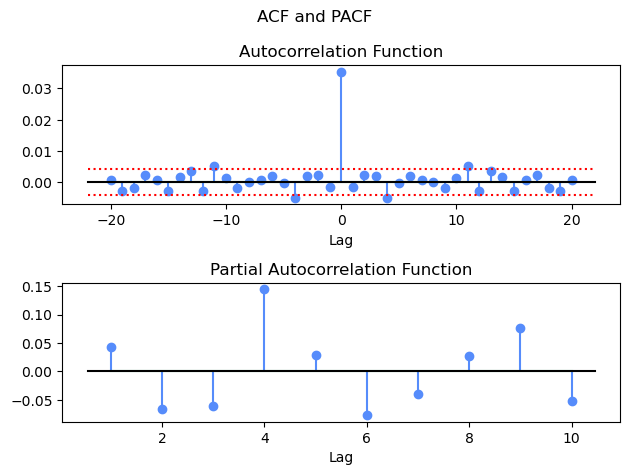

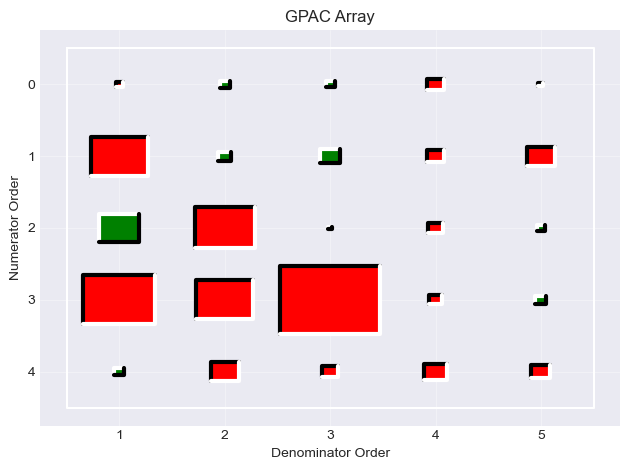

pval: 0.02130896745553046
alpha: 0.05
pr: 0.9786910325444695
q: 30.774215096981447
Portmanteau test:  Q = 30.77,  df = 17,  p-value = 0.021
Result: FAIL


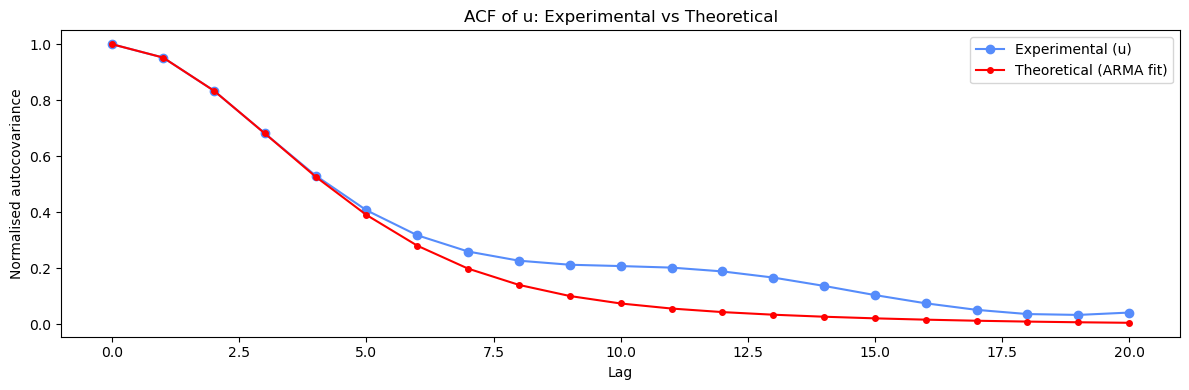

In [5]:
e_u = u - pmod_u.predict(u)
uracf, urpacf, urgpac = uniAnal(e_u, 20, 10)

passed_u, q_u, n_u, pval_u = uniChi(pmod_u, u)
print(f'Portmanteau test:  Q = {q_u:.2f},  df = {n_u},  p-value = {pval_u:.3f}')
print(f'Result: {"PASS" if passed_u else "FAIL"}')

var_e_u, _ = pmodmse(pmod_u, u)
lagmax = 21
acf_theory_u, _, _ = partoacf_pmod(pmod_u, var_e_u, lagmax)
uacf_s    = uacf.squeeze()
mid       = len(uacf_s) // 2
acf_exp_u = uacf_s[mid:mid + lagmax]

lags = np.arange(lagmax)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lags, acf_exp_u    / acf_exp_u[0],    'C0o-', label='Experimental (u)')
ax.plot(lags, acf_theory_u / acf_theory_u[0], 'r-o',  markersize=4, label='Theoretical (ARMA fit)')
ax.set_title('ACF of u: Experimental vs Theoretical')
ax.set_xlabel('Lag')
ax.set_ylabel('Normalised autocovariance')
ax.legend()
plt.tight_layout()
plt.show()

### Step 2c — Multivariate Analysis (u → y)

`multiAnal` prewhitens u using the fitted ARMA model, then computes:

- The estimated **impulse response** $\hat{g}(\tau)$ from u to y.
- The **residual autocorrelation** $r_v(\tau)$ of the disturbance $v = y - \hat{g} * u$.
- The **G GPAC** — identifies orders $n_b$ (B numerator) and $n_f$ (F denominator) of G.
- The **H GPAC** — identifies orders $n_c$ (C numerator) and $n_d$ (D denominator) of H.

The lag at which $\hat{g}(\tau)$ first becomes significantly non-zero gives the pure delay $k$.

Prewhitening input for impulse response estimation, please wait...
Selecting the best ARMA prediction model
arma: Combination 1 out of 12 total  [nc=0, nd=1].  aic = -2.2348, bic = -2.2223
arma: Combination 2 out of 12 total  [nc=0, nd=2].  aic = -3.2042, bic = -3.1793
arma: Combination 3 out of 12 total  [nc=0, nd=3].  aic = -3.3220, bic = -3.2846
arma: Combination 4 out of 12 total  [nc=1, nd=1].  aic = -2.9441, bic = -2.9191
arma: Combination 5 out of 12 total  [nc=1, nd=2].  aic = -3.2891, bic = -3.2517
arma: Combination 6 out of 12 total  [nc=1, nd=3].  aic = -3.3308, bic = -3.2810
arma: Combination 7 out of 12 total  [nc=2, nd=1].  aic = -3.1488, bic = -3.1114
arma: Combination 8 out of 12 total  [nc=2, nd=2].  aic = -3.2995, bic = -3.2496
arma: Combination 9 out of 12 total  [nc=2, nd=3].  aic = -3.2891, bic = -3.2268
arma: Combination 10 out of 12 total  [nc=3, nd=1].  aic = -3.2934, bic = -3.2435
arma: Combination 11 out of 12 total  [nc=3, nd=2].  aic = -3.3483, bic = -3.2860

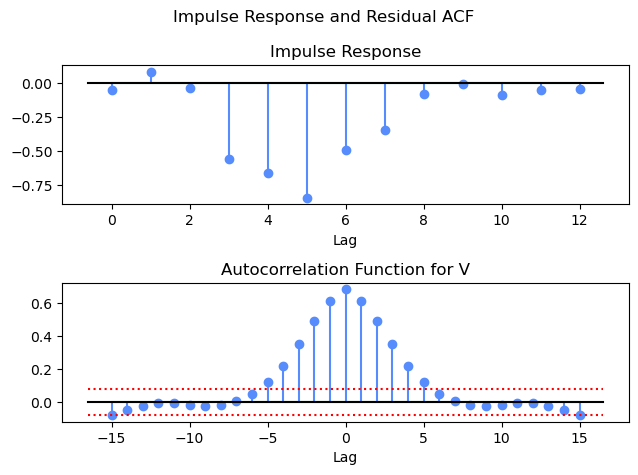

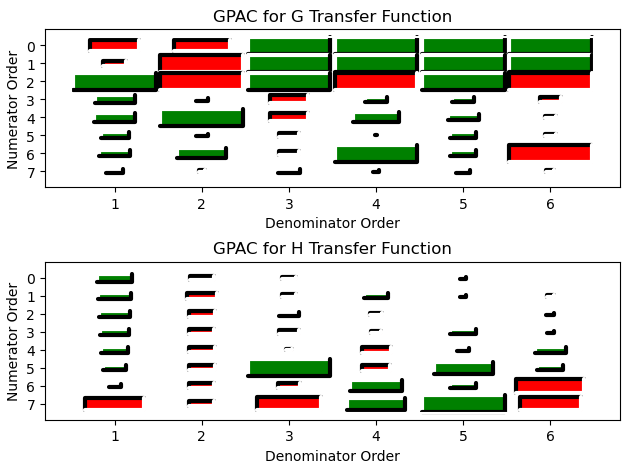

Impulse response (first 10 lags):
[-0.048   0.0834 -0.0345 -0.5582 -0.6574 -0.8422 -0.4945 -0.3426 -0.079
 -0.0064]

G GPAC:
[[-1.739 -2.304  5.     5.     5.     5.   ]
 [-0.414 -5.     5.     5.     5.     5.   ]
 [ 5.    -5.     5.    -5.     5.    -5.   ]
 [ 1.178  0.131 -1.091  0.367  0.392 -0.349]
 [ 1.281  5.    -1.04   1.561  0.712 -0.097]
 [ 0.587  0.115 -0.328  0.02   0.537 -0.118]
 [ 0.693  1.778 -0.324  5.     0.539 -5.   ]
 [ 0.231 -0.052  0.374  0.039  0.162 -0.063]]

H GPAC:
[[ 0.895 -0.424 -0.141  0.015  0.044 -0.008]
 [ 0.801 -0.668 -0.184  0.432  0.046 -0.056]
 [ 0.714 -0.54   0.299 -0.129  0.013  0.068]
 [ 0.631 -0.465 -0.312 -0.089  0.486  0.055]
 [ 0.546 -0.524 -0.041 -0.619  0.131  0.708]
 [ 0.417 -0.519  5.    -0.567  2.565  0.505]
 [ 0.122 -0.462 -0.385  2.027  0.499 -3.411]
 [-2.55  -0.473 -2.953  2.46   5.    -2.668]]


In [6]:
g_ir, rv, g_gpac, h_gpac = multiAnal(u, y, 8, 6, 8, 6)
print('Impulse response (first 10 lags):')
print(np.round(g_ir[:10], 4))
print('\nG GPAC:')
print(np.round(g_gpac, 3))
print('\nH GPAC:')
print(np.round(h_gpac, 3))

### Interpretation and Model Order Selection

**Impulse response** $\hat{g}(\tau)$:

- Near zero at $\tau = 0, 1, 2$; becomes non-zero at $\tau = 3$ → **delay $k = 3$**.

**G GPAC** (transfer function from u to y):

- Large values in the first three rows reflect the pure delay.
- After accounting for the delay, an approximately constant value appears in **column 2** of the effective GPAC — indicating $n_b = 2$ zeros and $n_f = 2$ poles in G.

**H GPAC** (noise transfer function):

- An approximately constant value in **column 2** starting from row 1 → $n_c = 0$, $n_d = 2$.

**Selected model:** `pmodel('bjtf', nb=[2], nf=[2], nc=[0], nd=[2], delay=[3])`

## Step 3 — Estimate Parameters

We estimate the BJTF model using the Levenberg-Marquardt algorithm.  The output y must be the **first** argument to `estimate` and the input u the **second**.

The selected model has $n_b + n_f + n_c + n_d = 2 + 2 + 0 + 2 = 6$ free parameters.

Input may not be zero mean sequences.
Epoch 0/50 Time 0.028278112411499023 PMODMSE 9.027646930088096/0.01 Gradient 3891.372092910378/0.0001 mu 0.001/10000000000.0


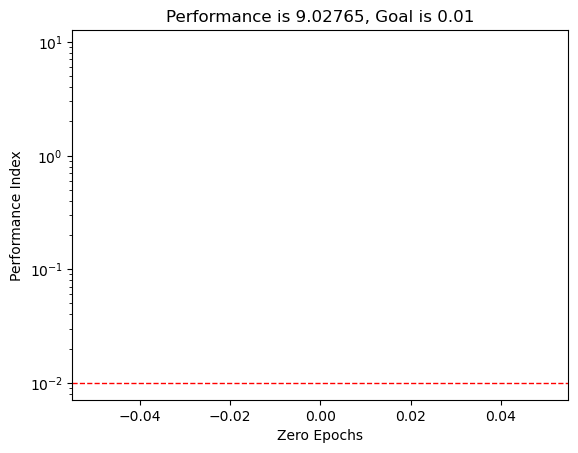

Epoch 10/50 Time 0.30186915397644043 PMODMSE 0.05687550163034918/0.01 Gradient 0.0021080390927325212/0.0001 mu 1.0000000000000005e-08/10000000000.0


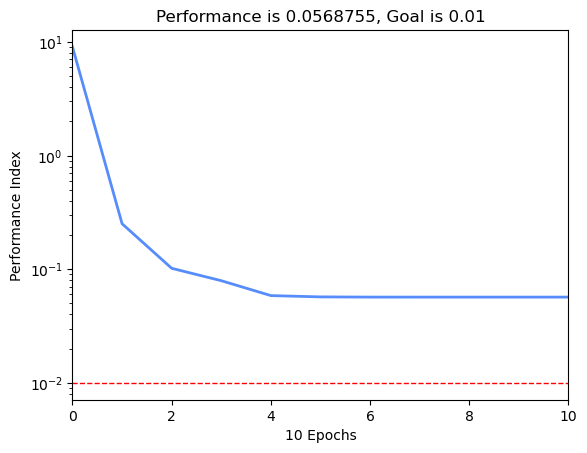

2.906702857883076e-05 0.0001
Epoch 13/50 Time 0.4688451290130615 PMODMSE 0.056875501536003514/0.01 Gradient 2.906702857883076e-05/0.0001 mu 1.0000000000000006e-11/10000000000.0


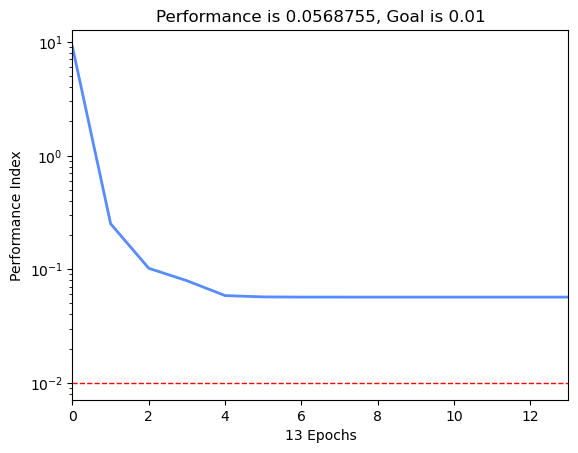

ESTIMLM, Minimum gradient reached, performance goal was not met.




In [7]:
pmod_bjtf = pmodel('bjtf', nb=[2], nf=[2], nc=[0], nd=[2], delay=[3], diff=[0], per=[])
pmod_bjtf.estimParams.epochs = 50
pmod_bjtf.estimParams.goal   = 0.01
pmod_bjtf, trec_bjtf, stat_bjtf = estimate(pmod_bjtf, y, u)

Parameter estimates — BJTF model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  b0      -0.5323       0.1483   (   -0.6805,    -0.3840)
  b1      -0.3706       0.2935   (   -0.6641,    -0.0771)
  b2      -0.5084       0.3111   (   -0.8195,    -0.1973)
  d1      -1.5287       0.0932   (   -1.6219,    -1.4355)
  d2       0.6295       0.0981   (    0.5314,     0.7276)
  f1      -0.5666       0.4134   (   -0.9799,    -0.1532)
  f2       0.0125       0.2857   (   -0.2732,     0.2983)

  Residual std  σ = 0.238486
  Residual var  σ² = 0.056876


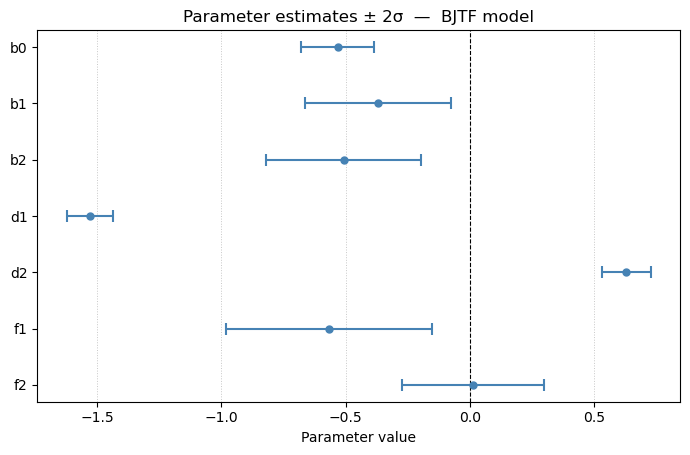

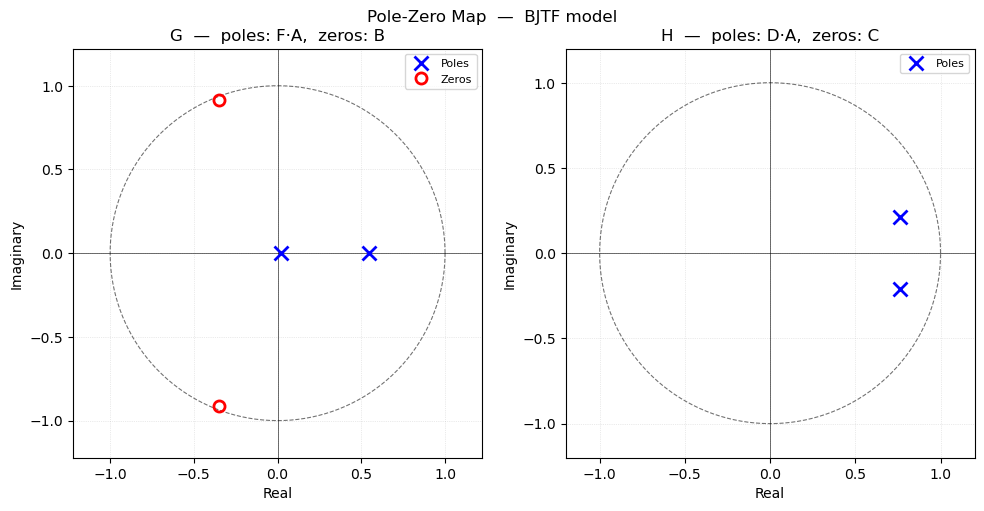

In [8]:
pmoddisp(pmod_bjtf, stat_bjtf)
pmodpzplot(pmod_bjtf)
plt.show()

The parameter table shows all estimates with 95% confidence intervals.  Note that **f₂** may have a wide interval that includes zero — suggesting $n_f$ could be reduced from 2 to 1.  The `selpmod` search in Step 5 will check this.

The pole-zero map shows G (B zeros, F poles) and H (C zeros, D poles) separately.  No pole-zero cancellations are visible — no further order reduction is indicated from this plot alone.

## Step 4 — Validate the Model

For BJTF models we apply three complementary checks:

1. **Whiteness and cross-correlation tests** — `multiChi` applies two chi-square tests on the one-step prediction errors $e(t) = y(t) - \hat{y}(t|t-1)$:
   - **Q statistic**: residuals are white noise (ACF test).  Pass: $p_Q > 0.05$.
   - **S statistic**: residuals are uncorrelated with the prewhitened input.  Pass: $p_S > 0.05$.
2. **Theoretical vs experimental impulse response** — `partoacf_pmod` computes the theoretical impulse response of $G(q^{-1}) = B(q^{-1})/F(q^{-1})\,q^{-k}$, which should match the experimental impulse response $\hat{g}(\tau)$ from `multiAnal` in Step 2.
3. **Theoretical vs experimental H autocorrelation** — `partoacf_pmod` also computes the theoretical ACF of $v(t) = H(q^{-1})e(t)$, which should match the residual autocorrelation $r_v(\tau)$ from `multiAnal`.

Prewhitening input, please wait...
Selecting the best ARMA prediction model
arma: Combination 1 out of 12 total  [nc=0, nd=1].  aic = -2.2348, bic = -2.2223
arma: Combination 2 out of 12 total  [nc=0, nd=2].  aic = -3.2042, bic = -3.1793
arma: Combination 3 out of 12 total  [nc=0, nd=3].  aic = -3.3220, bic = -3.2846
arma: Combination 4 out of 12 total  [nc=1, nd=1].  aic = -2.9441, bic = -2.9191
arma: Combination 5 out of 12 total  [nc=1, nd=2].  aic = -3.2891, bic = -3.2517
arma: Combination 6 out of 12 total  [nc=1, nd=3].  aic = -3.3308, bic = -3.2810
arma: Combination 7 out of 12 total  [nc=2, nd=1].  aic = -3.1488, bic = -3.1114
arma: Combination 8 out of 12 total  [nc=2, nd=2].  aic = -3.2995, bic = -3.2496
arma: Combination 9 out of 12 total  [nc=2, nd=3].  aic = -3.3260, bic = -3.2637
arma: Combination 10 out of 12 total  [nc=3, nd=1].  aic = -3.2934, bic = -3.2435
arma: Combination 11 out of 12 total  [nc=3, nd=2].  aic = -3.3483, bic = -3.2860
arma: Combination 12 out of 12 

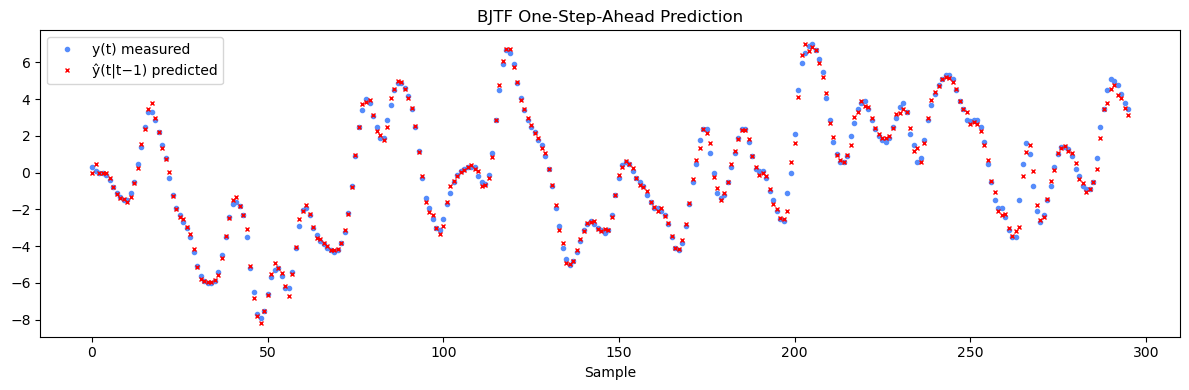

In [9]:
pass_arr, q_val, pvalq, s_val, pvals, nq, ns = multiChi(pmod_bjtf, y, u)
print(f'Q: Q = {q_val:.2f},  df = {nq},  p-value = {pvalq:.3f},  pass = {bool(pass_arr[0])}')
print(f'S: S = {s_val:.2f},  df = {ns},  p-value = {pvals:.3f},  pass = {bool(pass_arr[1])}')

y_pred_bjtf = pmod_bjtf.predict(y, u)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y,           'C0o', ms=3, label='y(t) measured')
ax.plot(y_pred_bjtf, 'rx',  ms=3, label='ŷ(t|t−1) predicted')
ax.set_title('BJTF One-Step-Ahead Prediction')
ax.set_xlabel('Sample')
ax.legend()
plt.tight_layout()
plt.show()

Both tests should pass (p-values $> 0.05$): residuals consistent with white noise and uncorrelated with the prewhitened input.  The prediction plot shows the model tracking the measured output closely.

### Check 2 — Theoretical vs Experimental Impulse Response

The theoretical impulse response of $G(q^{-1}) = B(q^{-1})/F(q^{-1})\,q^{-k}$ is computed from the estimated coefficients using `partoacf_pmod` and compared with the experimental impulse response $\hat{g}(\tau)$ returned by `multiAnal` in Step 2.  The pure delay $k = 3$ should appear as three leading zeros in both.

Noise variance estimate: 0.056865


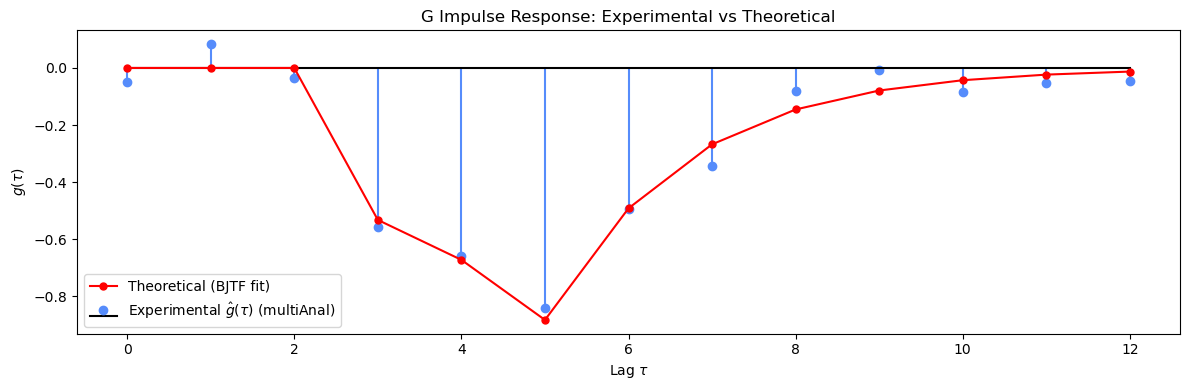

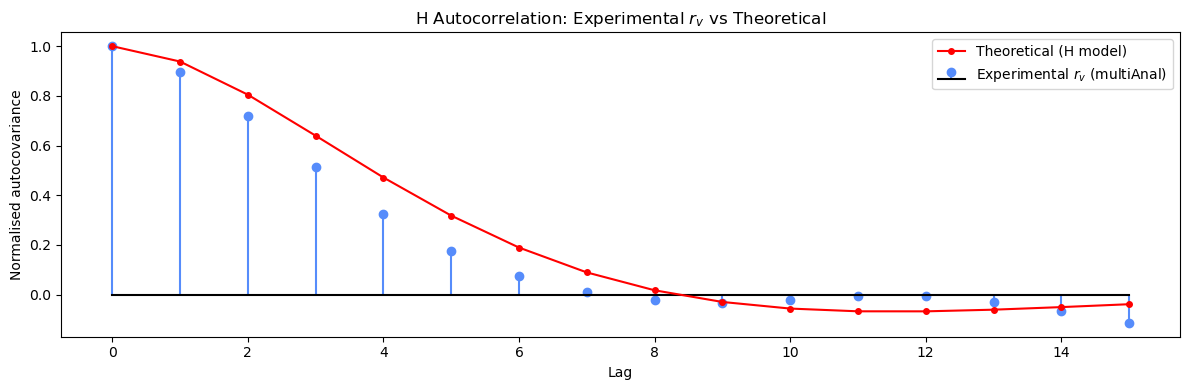

In [10]:
# Noise variance from one-step prediction errors
e_bjtf = y - pmod_bjtf.predict(y, u)
var_e_bjtf = np.var(e_bjtf)
print(f'Noise variance estimate: {var_e_bjtf:.6f}')

# Theoretical impulse response (G) and H ACF from the fitted model.
# lagmax covers both the impulse response length and rv positive-lag range.
lagmax_g = len(g_ir)                        # match experimental g_ir length
lagmax_h = rv.squeeze().shape[0] // 2 + 1  # positive lags of rv
lagmax_c = max(lagmax_g, lagmax_h)
acf_theory_H, _, g_ir_theory = partoacf_pmod(pmod_bjtf, var_e_bjtf, lagmax_c)

# ── Plot 1: G impulse response ──────────────────────────────────────────────
lags_g = np.arange(lagmax_g)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(lags_g, g_ir, linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=r'Experimental $\hat{g}(\tau)$ (multiAnal)')
ax.plot(lags_g, g_ir_theory[:lagmax_g], 'r-o', markersize=5, linewidth=1.5,
        label='Theoretical (BJTF fit)')
ax.set_title('G Impulse Response: Experimental vs Theoretical')
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'$g(\tau)$')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: H autocorrelation — rv vs theoretical ───────────────────────────
rv_s   = rv.squeeze()
mid_rv = len(rv_s) // 2
rv_pos = rv_s[mid_rv:mid_rv + lagmax_h]

acf_H_norm = acf_theory_H[:lagmax_h] / acf_theory_H[0]
rv_norm    = rv_pos / rv_pos[0]

lags_h = np.arange(lagmax_h)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(lags_h, rv_norm, linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=r'Experimental $r_v$ (multiAnal)')
ax.plot(lags_h, acf_H_norm, 'r-o', markersize=4, linewidth=1.5,
        label='Theoretical (H model)')
ax.set_title(r'H Autocorrelation: Experimental $r_v$ vs Theoretical')
ax.set_xlabel('Lag')
ax.set_ylabel('Normalised autocovariance')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — Automated Model Selection with `selpmod`

`selpmod` searches a grid of BJTF structures and selects the best by AIC and BIC.

| Parameter | Values |
|-----------|--------|
| $n_b$ (B numerator) | 1, 2 |
| $n_c$ (C numerator) | 0, 1, 2 |
| $n_d$ (D denominator) | 0, 1, 2 |
| $n_f$ (F denominator) | 0, 1, 2 |
| Delay $k$ | 3 (fixed) |

$2 \times 3^3 = 54$ total combinations.  The BIC-optimal model is expected to reduce $n_f$ from 2 to 1, removing the marginally significant $f_2$.

In [11]:
bjtf_spec = {
    'models': [{
        'type':  'bjtf',
        'nb':    [1, 2],
        'nc':    [0, 1, 2],
        'nd':    [0, 1, 2],
        'nf':    [0, 1, 2],
        'delay': [3],
        'diff':  [0]
    }]
}
result_bjtf = selpmod(bjtf_spec, y, u)
print('\nModel selection complete.')

Input may not be zero mean sequences.
Selecting the best BJTF prediction model
bjtf: Combination 1 out of 54 total  [nb=1, nc=0, nd=0, nf=0, delay=3].  aic = 0.2919, bic = 0.3168
Input may not be zero mean sequences.
bjtf: Combination 2 out of 54 total  [nb=1, nc=0, nd=0, nf=1, delay=3].  aic = -0.3650, bic = -0.3276
Input may not be zero mean sequences.
bjtf: Combination 3 out of 54 total  [nb=1, nc=0, nd=0, nf=2, delay=3].  aic = -0.3591, bic = -0.3092
Input may not be zero mean sequences.
bjtf: Combination 4 out of 54 total  [nb=1, nc=0, nd=1, nf=0, delay=3].  aic = -1.5643, bic = -1.5269
Input may not be zero mean sequences.
bjtf: Combination 5 out of 54 total  [nb=1, nc=0, nd=1, nf=1, delay=3].  aic = -2.3537, bic = -2.3038
Input may not be zero mean sequences.
bjtf: Combination 6 out of 54 total  [nb=1, nc=0, nd=1, nf=2, delay=3].  aic = -2.3875, bic = -2.3252
Input may not be zero mean sequences.
bjtf: Combination 7 out of 54 total  [nb=1, nc=0, nd=2, nf=0, delay=3].  aic = -2.1

Best BJTF model by BIC:
  b = [[-0.5315175301678751, -0.3798226498270445, -0.517306053320867]]
  f = [array([-0.54919241])]
  c = [[]]
  d = [array([-1.52862716,  0.6295388 ])]
  delay = [3]
Parameter estimates — BJTF model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  b0      -0.5315       0.1472   (   -0.6787,    -0.3844)
  b1      -0.3798       0.2026   (   -0.5824,    -0.1772)
  b2      -0.5173       0.2123   (   -0.7296,    -0.3050)
  d1      -1.5286       0.0932   (   -1.6218,    -1.4355)
  d2       0.6295       0.0981   (    0.5315,     0.7276)
  f1      -0.5492       0.0750   (   -0.6242,    -0.4742)

  Residual std  σ = 0.238489
  Residual var  σ² = 0.056877


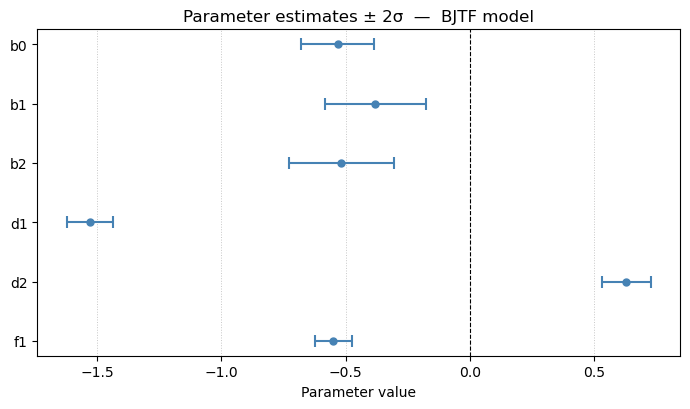

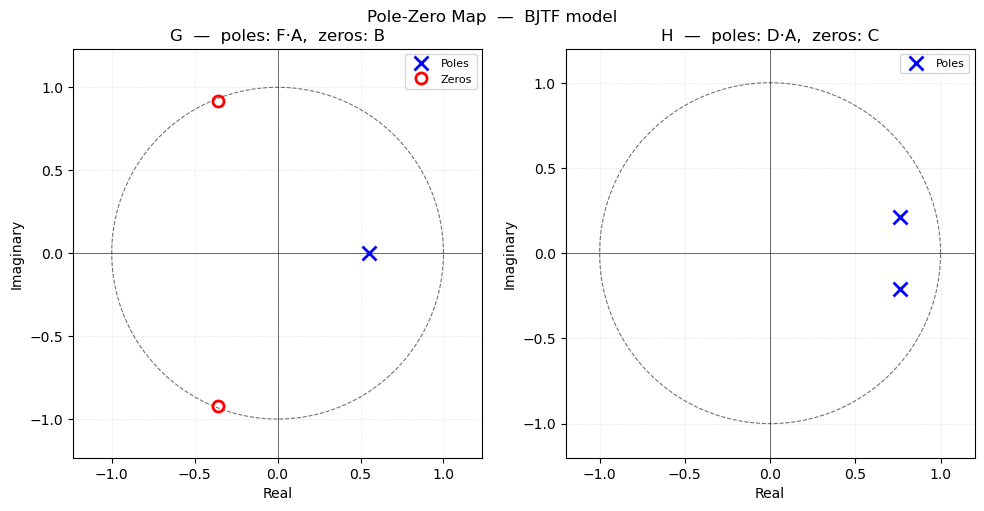

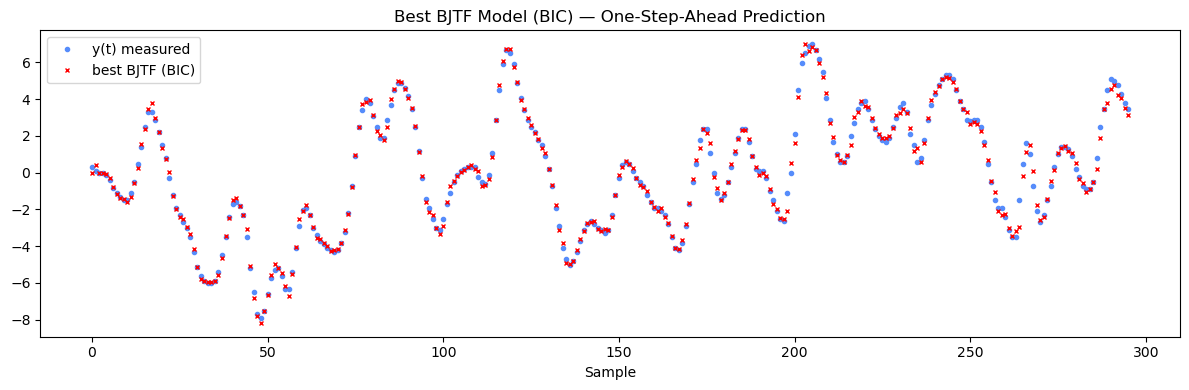

Prewhitening input, please wait...
Selecting the best ARMA prediction model
arma: Combination 1 out of 12 total  [nc=0, nd=1].  aic = -2.2348, bic = -2.2223
arma: Combination 2 out of 12 total  [nc=0, nd=2].  aic = -3.2042, bic = -3.1793
arma: Combination 3 out of 12 total  [nc=0, nd=3].  aic = -3.3220, bic = -3.2846
arma: Combination 4 out of 12 total  [nc=1, nd=1].  aic = -2.9441, bic = -2.9191
arma: Combination 5 out of 12 total  [nc=1, nd=2].  aic = -3.2891, bic = -3.2517
arma: Combination 6 out of 12 total  [nc=1, nd=3].  aic = -3.3308, bic = -3.2810
arma: Combination 7 out of 12 total  [nc=2, nd=1].  aic = -3.1488, bic = -3.1114
arma: Combination 8 out of 12 total  [nc=2, nd=2].  aic = -3.2995, bic = -3.2496
arma: Combination 9 out of 12 total  [nc=2, nd=3].  aic = -3.3260, bic = -3.2637
arma: Combination 10 out of 12 total  [nc=3, nd=1].  aic = -3.2934, bic = -3.2435
arma: Combination 11 out of 12 total  [nc=3, nd=2].  aic = -3.3483, bic = -3.2860
arma: Combination 12 out of 12 

In [12]:
pmod_bic = result_bjtf['bjtf']['bicmod']
stat_bic = result_bjtf['bjtf']['bicstat']

print('Best BJTF model by BIC:')
print(f'  b = {pmod_bic.b}')
print(f'  f = {pmod_bic.f}')
print(f'  c = {pmod_bic.c}')
print(f'  d = {pmod_bic.d}')
print(f'  delay = {pmod_bic.delay}')

pmoddisp(pmod_bic, stat_bic)
pmodpzplot(pmod_bic)
plt.show()

y_pred_bic = pmod_bic.predict(y, u)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y,          'C0o', ms=3, label='y(t) measured')
ax.plot(y_pred_bic, 'rx',  ms=3, label='best BJTF (BIC)')
ax.set_title('Best BJTF Model (BIC) — One-Step-Ahead Prediction')
ax.set_xlabel('Sample')
ax.legend()
plt.tight_layout()
plt.show()

pass2, q2, pvalq2, s2, pvals2, nq2, ns2 = multiChi(pmod_bic, y, u)
print(f'Q: Q={q2:.2f},  df={nq2},  p={pvalq2:.3f},  pass={bool(pass2[0])}')
print(f'S: S={s2:.2f},  df={ns2},  p={pvals2:.3f},  pass={bool(pass2[1])}')

aic_bjtf = pmodaic(pmod_bic, y, u)
bic_bjtf = pmodbic(pmod_bic, y, u)
print(f'\nBest BJTF (BIC)  —  AIC = {aic_bjtf:.4f},  BIC = {bic_bjtf:.4f}')

## Comparison: ARMAX Model

The ARMAX model is an **equation-error** model:

$$A(q^{-1})\,y(t) = B(q^{-1})\,u(t-k) + C(q^{-1})\,e(t)$$

Both transfer functions share the same denominator A:

$$G = \frac{B}{A}, \qquad H = \frac{C}{A}$$

ARMAX cannot independently model G and H dynamics.  When the true G and H have different poles — as is typically the case — the model compensates, and the pole-zero plot often shows approximate cancellations in one transfer function.

Since there are no dedicated preliminary analysis tools for ARMAX, we go directly to `selpmod`.

In [13]:
armax_spec = {
    'models': [{
        'type':  'armax',
        'na':    [1, 2, 3],
        'nb':    [1, 2, 3, 4],
        'nc':    [0, 1, 2],
        'delay': [3],
        'diff':  [0]
    }]
}
result_armax = selpmod(armax_spec, y, u)
print('\nModel selection complete.')

Input may not be zero mean sequences.
Selecting the best ARMAX prediction model
armax: Combination 1 out of 36 total  [na=1, nb=1, nc=0, delay=3].  aic = -1.9191, bic = -1.8817
Input may not be zero mean sequences.
armax: Combination 2 out of 36 total  [na=1, nb=1, nc=1, delay=3].  aic = -2.4496, bic = -2.3998
Input may not be zero mean sequences.
armax: Combination 3 out of 36 total  [na=1, nb=1, nc=2, delay=3].  aic = -2.6647, bic = -2.6024
Input may not be zero mean sequences.
armax: Combination 4 out of 36 total  [na=1, nb=2, nc=0, delay=3].  aic = -1.9828, bic = -1.9329
Input may not be zero mean sequences.
armax: Combination 5 out of 36 total  [na=1, nb=2, nc=1, delay=3].  aic = -2.4447, bic = -2.3823
Input may not be zero mean sequences.
armax: Combination 6 out of 36 total  [na=1, nb=2, nc=2, delay=3].  aic = -2.6670, bic = -2.5922
Input may not be zero mean sequences.
armax: Combination 7 out of 36 total  [na=1, nb=3, nc=0, delay=3].  aic = -2.2205, bic = -2.1582
Input may not

Best ARMAX model by AIC:
  a = [array([-1.63770408,  0.9640853 , -0.23763   ])]
  b = [array([-0.5337536 ,  0.20677525, -0.23656535,  0.27113907])]
  c = [array([-0.11139344,  0.24976458])]
  delay = [3]
Parameter estimates — ARMAX model
---------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  a1      -1.6377       0.3505   (   -1.9882,    -1.2872)
  a2       0.9641       0.5096   (    0.4545,     1.4737)
  a3      -0.2376       0.2004   (   -0.4380,    -0.0373)
  b0      -0.5338       0.1475   (   -0.6813,    -0.3862)
  b1       0.2068       0.3500   (   -0.1433,     0.5568)
  b2      -0.2366       0.3710   (   -0.6075,     0.1344)
  b3       0.2711       0.2457   (    0.0254,     0.5169)
  c1      -0.1114       0.3563   (   -0.4677,     0.2449)
  c2       0.2498       0.1482   (    0.1016,     0.3980)

  Residual std  σ = 0.235320
  Residual var  σ² = 0.055376


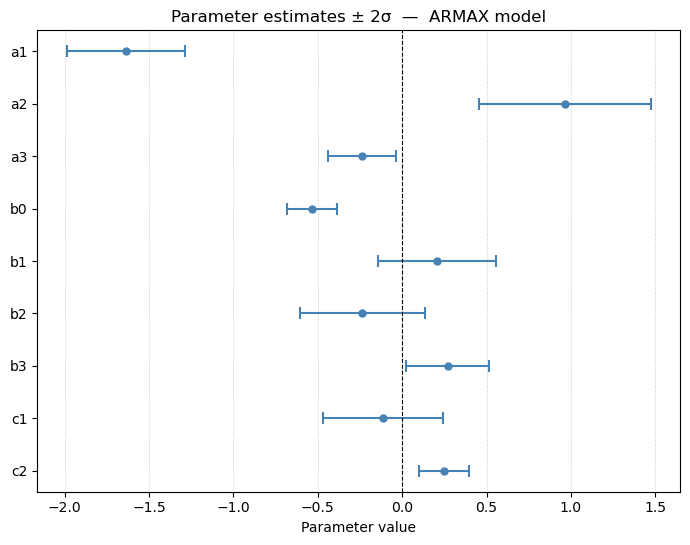

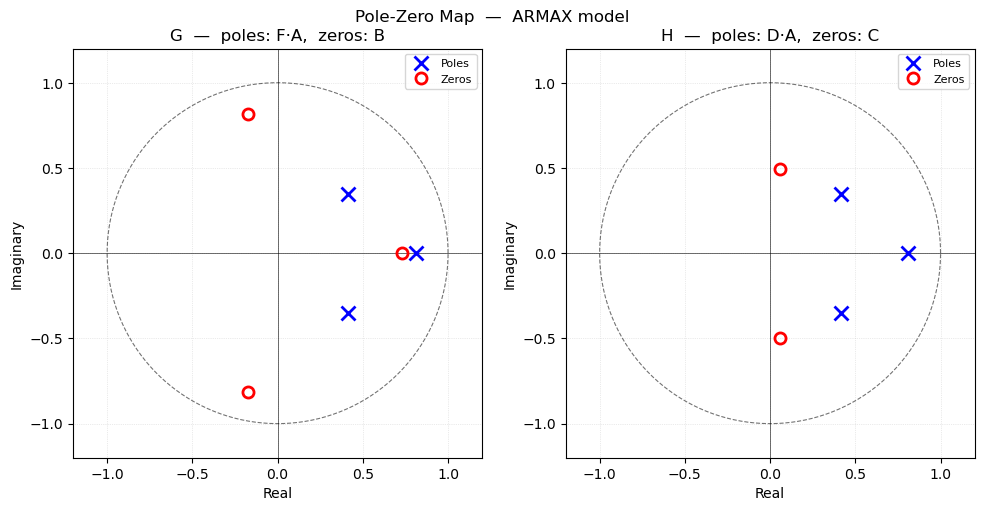

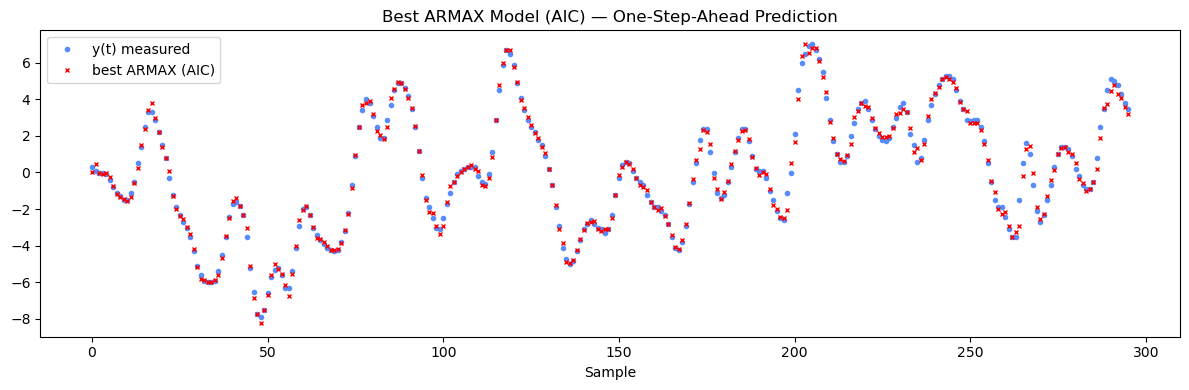


Best ARMAX (AIC)  —  AIC = -2.8328,  BIC = -2.7206


In [14]:
pmod_armax = result_armax['armax']['aicmod']
stat_armax = result_armax['armax']['aicstat']

print('Best ARMAX model by AIC:')
print(f'  a = {pmod_armax.a}')
print(f'  b = {pmod_armax.b}')
print(f'  c = {pmod_armax.c}')
print(f'  delay = {pmod_armax.delay}')

pmoddisp(pmod_armax, stat_armax)
pmodpzplot(pmod_armax)
plt.show()

y_pred_armax = pmod_armax.predict(y, u)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y,            'C0o', ms=3, label='y(t) measured')
ax.plot(y_pred_armax, 'rx',  ms=3, label='best ARMAX (AIC)')
ax.set_title('Best ARMAX Model (AIC) — One-Step-Ahead Prediction')
ax.set_xlabel('Sample')
ax.legend()
plt.tight_layout()
plt.show()

aic_armax = pmodaic(pmod_armax, y, u)
bic_armax = pmodbic(pmod_armax, y, u)
print(f'\nBest ARMAX (AIC)  —  AIC = {aic_armax:.4f},  BIC = {bic_armax:.4f}')

There are some parameters with error bars that include 0, but they don't correspond to the final parameter, so we could not reduce the models from that. Notice that there is an approximate pole/zero cancellation in the G transfer function. Since both G and H have the same denominator in the ARMAX model, we don't have the flexibility to reduce the orders of B and A, because the root of A is not cancelled in the H transfer function. The approximate cancellation is a diagnostic sign that the shared-pole constraint is forcing the model to absorb noise-model dynamics into the input transfer function.  This is a well-known limitation of equation-error models; see Ljung (1999), *System Identification: Theory for the User*, Ch. 4.

Noise variance estimate: 0.055349


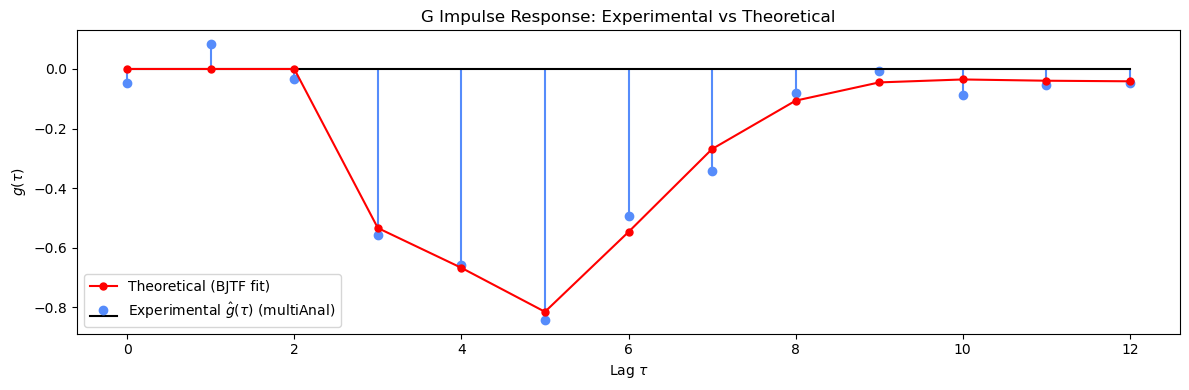

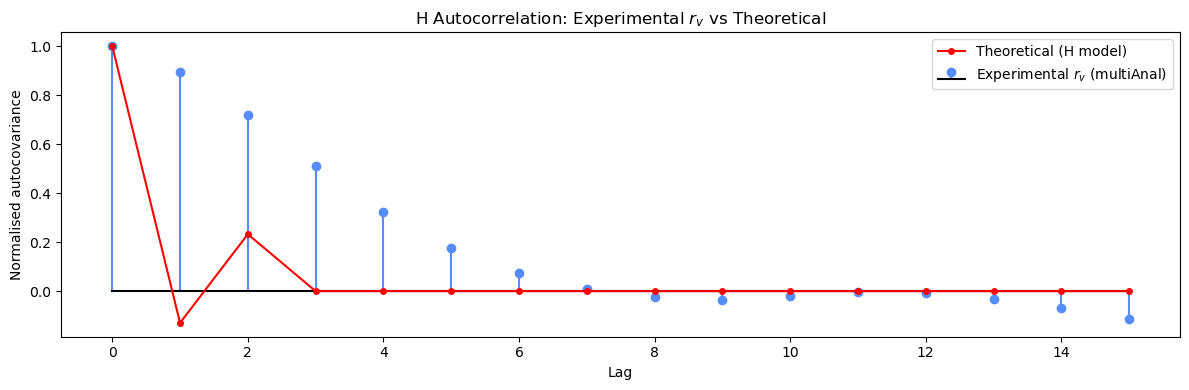

In [17]:
# Noise variance from one-step prediction errors
e_armax = y - pmod_armax.predict(y, u)
var_e_armax = np.var(e_armax)
print(f'Noise variance estimate: {var_e_armax:.6f}')

# Theoretical impulse response (G) and H ACF from the fitted model.
# lagmax covers both the impulse response length and rv positive-lag range.
lagmax_g = len(g_ir)                        # match experimental g_ir length
lagmax_h = rv.squeeze().shape[0] // 2 + 1  # positive lags of rv
lagmax_c = max(lagmax_g, lagmax_h)
acf_theory_H, _, g_ir_theory = partoacf_pmod(pmod_armax, var_e_armax, lagmax_c)

# ── Plot 1: G impulse response ──────────────────────────────────────────────
lags_g = np.arange(lagmax_g)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(lags_g, g_ir, linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=r'Experimental $\hat{g}(\tau)$ (multiAnal)')
ax.plot(lags_g, g_ir_theory[:lagmax_g], 'r-o', markersize=5, linewidth=1.5,
        label='Theoretical (BJTF fit)')
ax.set_title('G Impulse Response: Experimental vs Theoretical')
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'$g(\tau)$')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: H autocorrelation — rv vs theoretical ───────────────────────────
rv_s   = rv.squeeze()
mid_rv = len(rv_s) // 2
rv_pos = rv_s[mid_rv:mid_rv + lagmax_h]

acf_H_norm = acf_theory_H[:lagmax_h] / acf_theory_H[0]
rv_norm    = rv_pos / rv_pos[0]

lags_h = np.arange(lagmax_h)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(lags_h, rv_norm, linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=r'Experimental $r_v$ (multiAnal)')
ax.plot(lags_h, acf_H_norm, 'r-o', markersize=4, linewidth=1.5,
        label='Theoretical (H model)')
ax.set_title(r'H Autocorrelation: Experimental $r_v$ vs Theoretical')
ax.set_xlabel('Lag')
ax.set_ylabel('Normalised autocovariance')
ax.legend()
plt.tight_layout()
plt.show()

The impulse response of the G transfer function is accurate, but the ACF of the disturbance is much less accurate than with the BJTF model. The ARMAX model has limited flexibility in representing the H transfer function, since it can only adjust the numerator.

## Comparison: ARX Model

The **ARX** model is the simplest equation-error model — no MA term:

$$A(q^{-1})\,y(t) = B(q^{-1})\,u(t-k) + e(t)$$

The noise transfer function is $H = 1/A$, so the noise is forced to be a pure AR process.  ARX is the cheapest to estimate (linear least squares) but will generally have higher AIC/BIC than BJTF or ARMAX unless the disturbance is genuinely AR.

In PredictMod notation: `pmodel('arx', na=[na], nb=[nb], delay=[k])`.

In [15]:
arx_spec = {
    'models': [{
        'type':  'arx',
        'na':    [1, 2, 3],
        'nb':    [1, 2, 3],
        'delay': [3]
    }]
}
result_arx = selpmod(arx_spec, y, u)
print('\nModel selection complete.')

Input may not be zero mean sequences.
Selecting the best ARX prediction model
arx: Combination 1 out of 9 total  [na=1, nb=1, delay=3].  aic = -1.9191, bic = -1.8817
Input may not be zero mean sequences.
arx: Combination 2 out of 9 total  [na=1, nb=2, delay=3].  aic = -1.9828, bic = -1.9329
Input may not be zero mean sequences.
arx: Combination 3 out of 9 total  [na=1, nb=3, delay=3].  aic = -2.2205, bic = -2.1582
Input may not be zero mean sequences.
arx: Combination 4 out of 9 total  [na=2, nb=1, delay=3].  aic = -2.7206, bic = -2.6708
Input may not be zero mean sequences.
arx: Combination 5 out of 9 total  [na=2, nb=2, delay=3].  aic = -2.7628, bic = -2.7005
Input may not be zero mean sequences.
arx: Combination 6 out of 9 total  [na=2, nb=3, delay=3].  aic = -2.7934, bic = -2.7186
Input may not be zero mean sequences.
arx: Combination 7 out of 9 total  [na=3, nb=1, delay=3].  aic = -2.7674, bic = -2.7051
Input may not be zero mean sequences.
arx: Combination 8 out of 9 total  [na=3

Best ARX model by BIC:
  a = [array([-1.55511949,  0.7450646 , -0.12067685])]
  b = [array([-0.52325805,  0.13718028, -0.16599537,  0.33087448])]
  delay = [3]
Parameter estimates — ARX model
-------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  a1      -1.5551       0.1130   (   -1.6681,    -1.4421)
  a2       0.7451       0.1812   (    0.5638,     0.9263)
  a3      -0.1207       0.0854   (   -0.2061,    -0.0353)
  b0      -0.5233       0.1492   (   -0.6724,    -0.3741)
  b1       0.1372       0.3291   (   -0.1920,     0.4663)
  b2      -0.1660       0.3475   (   -0.5135,     0.1815)
  b3       0.3309       0.2049   (    0.1260,     0.5357)

  Residual std  σ = 0.239240
  Residual var  σ² = 0.057236


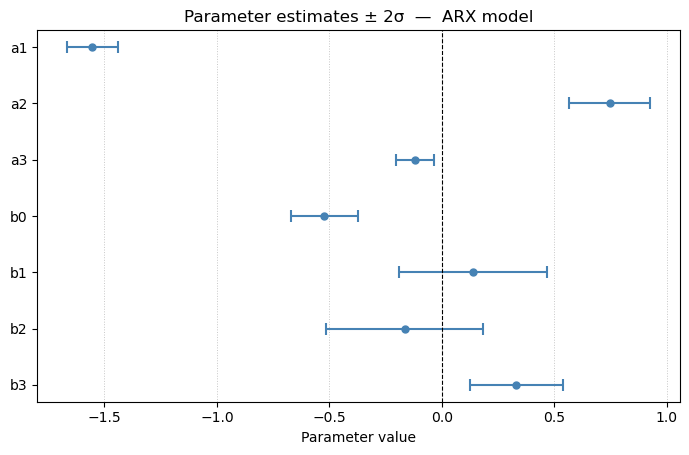

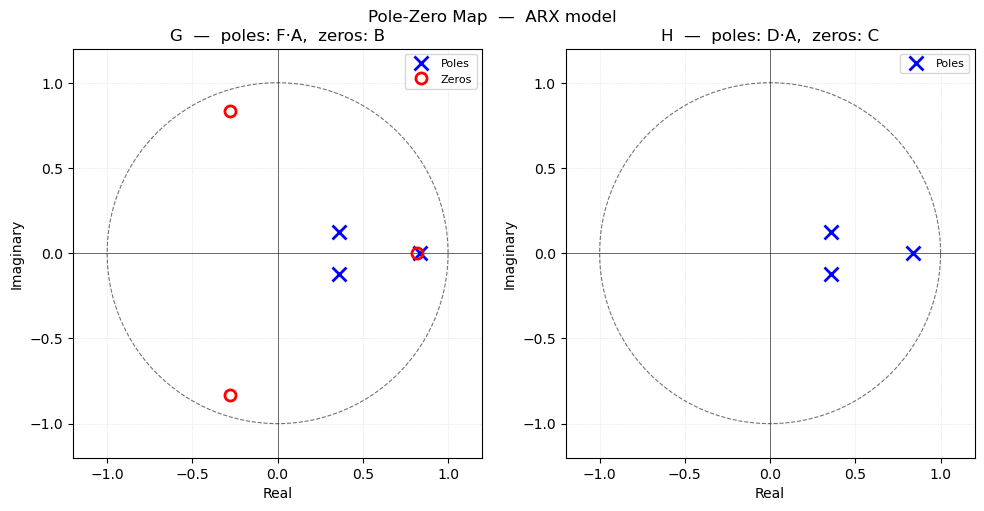

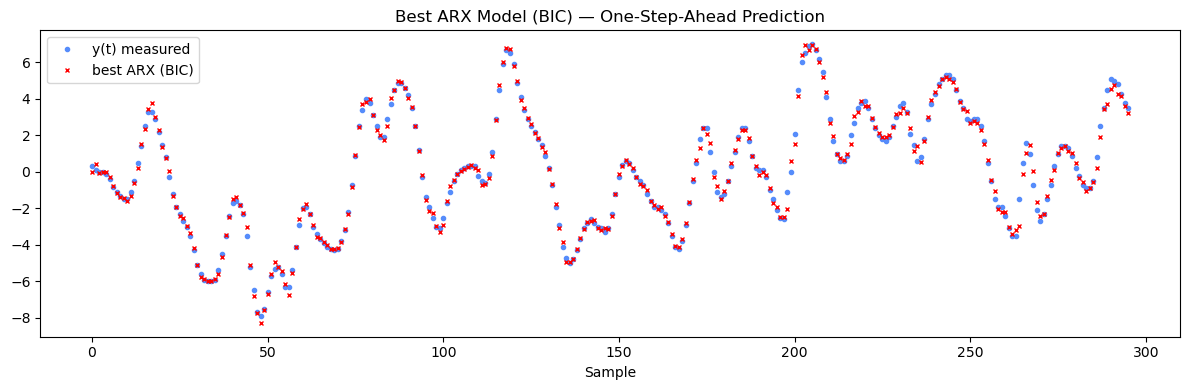


Best ARX (BIC)  —  AIC = -2.8133,  BIC = -2.7260


In [16]:
pmod_arx = result_arx['arx']['bicmod']
stat_arx = result_arx['arx']['bicstat']

print('Best ARX model by BIC:')
print(f'  a = {pmod_arx.a}')
print(f'  b = {pmod_arx.b}')
print(f'  delay = {pmod_arx.delay}')

pmoddisp(pmod_arx, stat_arx)
pmodpzplot(pmod_arx)
plt.show()

y_pred_arx = pmod_arx.predict(y, u)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y,           'C0o', ms=3, label='y(t) measured')
ax.plot(y_pred_arx,  'rx',  ms=3, label='best ARX (BIC)')
ax.set_title('Best ARX Model (BIC) — One-Step-Ahead Prediction')
ax.set_xlabel('Sample')
ax.legend()
plt.tight_layout()
plt.show()

aic_arx = pmodaic(pmod_arx, y, u)
bic_arx = pmodbic(pmod_arx, y, u)
print(f'\nBest ARX (BIC)  —  AIC = {aic_arx:.4f},  BIC = {bic_arx:.4f}')

Now let's see how closely the theoretical impulse response and disturbance ACF match with the experimental versions for the ARX model.

Noise variance estimate: 0.057205


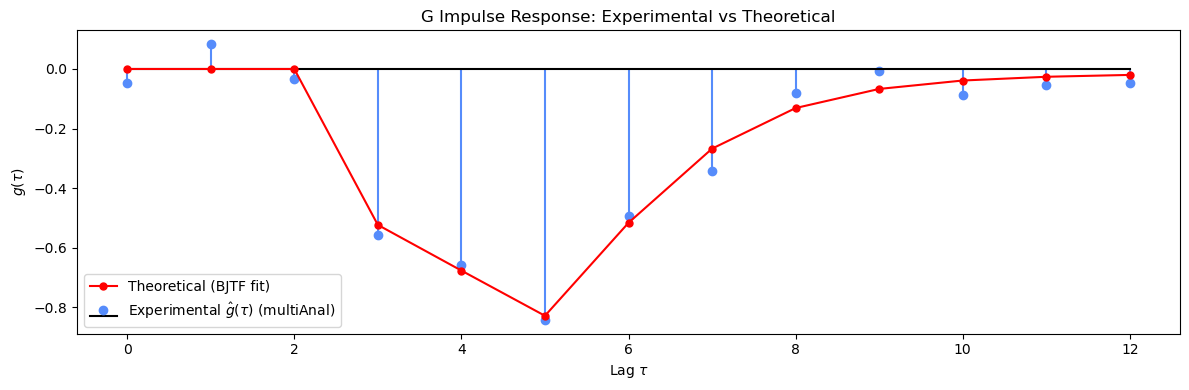

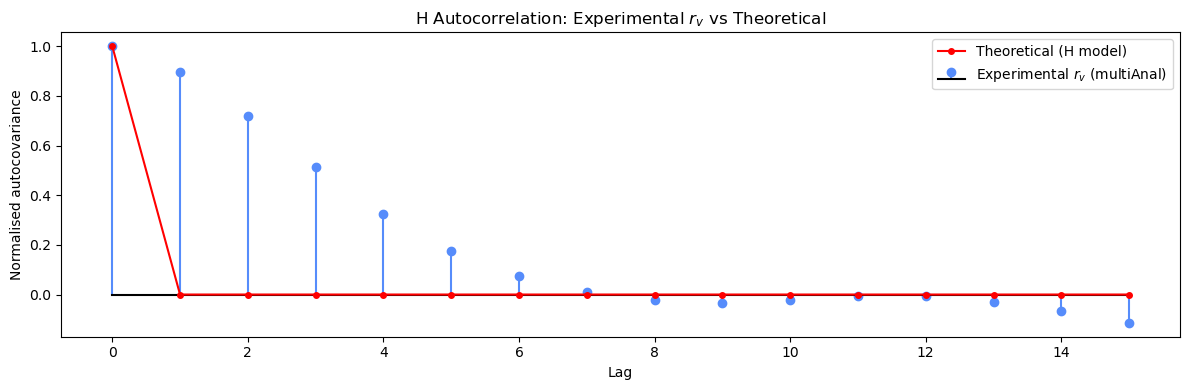

In [18]:
# Noise variance from one-step prediction errors
e_arx = y - pmod_arx.predict(y, u)
var_e_arx = np.var(e_arx)
print(f'Noise variance estimate: {var_e_arx:.6f}')

# Theoretical impulse response (G) and H ACF from the fitted model.
# lagmax covers both the impulse response length and rv positive-lag range.
lagmax_g = len(g_ir)                        # match experimental g_ir length
lagmax_h = rv.squeeze().shape[0] // 2 + 1  # positive lags of rv
lagmax_c = max(lagmax_g, lagmax_h)
acf_theory_H, _, g_ir_theory = partoacf_pmod(pmod_arx, var_e_arx, lagmax_c)

# ── Plot 1: G impulse response ──────────────────────────────────────────────
lags_g = np.arange(lagmax_g)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(lags_g, g_ir, linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=r'Experimental $\hat{g}(\tau)$ (multiAnal)')
ax.plot(lags_g, g_ir_theory[:lagmax_g], 'r-o', markersize=5, linewidth=1.5,
        label='Theoretical (BJTF fit)')
ax.set_title('G Impulse Response: Experimental vs Theoretical')
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'$g(\tau)$')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: H autocorrelation — rv vs theoretical ───────────────────────────
rv_s   = rv.squeeze()
mid_rv = len(rv_s) // 2
rv_pos = rv_s[mid_rv:mid_rv + lagmax_h]

acf_H_norm = acf_theory_H[:lagmax_h] / acf_theory_H[0]
rv_norm    = rv_pos / rv_pos[0]

lags_h = np.arange(lagmax_h)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(lags_h, rv_norm, linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=r'Experimental $r_v$ (multiAnal)')
ax.plot(lags_h, acf_H_norm, 'r-o', markersize=4, linewidth=1.5,
        label='Theoretical (H model)')
ax.set_title(r'H Autocorrelation: Experimental $r_v$ vs Theoretical')
ax.set_xlabel('Lag')
ax.set_ylabel('Normalised autocovariance')
ax.legend()
plt.tight_layout()
plt.show()

We can see that the impulse response for G is reasonably accurate, but the ACF of the disturbance is not accurate. This is expected, since the ARX model has no flexibility in setting the H transfer function.

## Conclusion

The system identification process for Box-Jenkins Series J (gas furnace) confirmed the **BJTF model** as the most flexible and interpretable choice for this input-output system.

**Summary of the four-step process:**

1. **Model class**: BJTF — separate G (input TF) and H (noise TF) polynomials.
2. **Order selection**: `uniAnal` on u → AR(3) for the input; `multiAnal` → impulse response identified delay $k = 3$; G GPAC identified $n_b = 2$, $n_f = 2$; H GPAC identified $n_c = 0$, $n_d = 2$.
3. **Estimation**: Levenberg-Marquardt converged cleanly; f₂ confidence interval included zero.
4. **Validation**: Both `multiChi` tests (Q and S) passed.
5. **Automated selection**: `selpmod` with BIC confirmed the model and reduced $n_f$ to 1.

**Model class comparison:**

| Model | G and H poles shared? | Flexibility | Typical AIC/BIC rank |
|-------|-----------------------|-------------|----------------------|
| BJTF  | No — estimated independently | Highest | Best |
| ARMAX | Yes, via A polynomial | Medium | Comparable |
| ARX   | Yes, no MA term | Lowest | Highest |

BJTF provides the clearest physical picture: G captures how changes in gas flow rate propagate to CO₂ output after a 3-sample delay, while H independently captures the stochastic disturbance dynamics.

**Reference:** Box, G. E. P., & Jenkins, G. M. (1976). *Time Series Analysis: Forecasting and Control* (Rev. ed.), Chapter 11.